In [3]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly_express as px
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

In [4]:
# connecting to database
connection = sqlite3.connect("/Users/beans/Desktop/M3Theme_Park_Analysis/data/themepark.db")
cursor = connection.cursor()

In [5]:
# query to find category, minutes waited and ratings
cat = """
SELECT category,wait_minutes, satisfaction_rating
FROM fact_ride_events fre
JOIN dim_attraction da ON da.attraction_id = fre.attraction_id
WHERE wait_minutes IS NOT NULL
"""

cursor.execute(cat)

In [6]:
# reading query to database
catdf = pd.read_sql_query(cat,connection)

display(catdf)



,category,wait_minutes,satisfaction_rating
0,Water,2,3
1,Kids,33,4
2,Water,79,1
3,Water,33,2
4,Kids,57,3
...,...,...,...
62,Thrill,28,3
63,Water,17,2
64,Thrill,5,5
65,Kids,7,1


<Axes: ylabel='Frequency'>

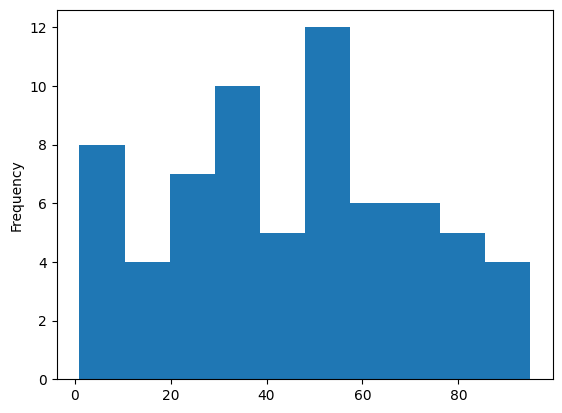

In [7]:
# displaying a .describe to see measures of central tendencies
# goal is to find a threshold to split "short wait time" vs "long wait time"
catdf['wait_minutes'].describe()

catdf['wait_minutes'].plot(kind='hist')
# doesn't seem skewed, somewhat normal



# Test One: Two Sample T-Test
Compares the longer wait times and their ratings to shorter wait times and their ratings.

### Null Hypothesis:
There is no difference in average ratings between rides with long wait times and short wait times.
### Alternative Hypothesis:
Rides with shorter wait times have higher average ratings than rides with longer wait times.

### This will show if wait times contribute to ratings by splitting into two groups,
Group 1: "Short Wait Times"  
Group 2: "Long Wait Times"

In [8]:
# taking the columns necessary for t-test
test = catdf[['category','wait_minutes','satisfaction_rating']]

testshort = test.copy()
#filtering to wait_minutes shorter or equal to the mean
testshort = testshort[testshort['wait_minutes'] <= testshort['wait_minutes'].mean()]
display('Short Wait Times:', testshort)

testlong = test.copy()
#filtering to wait minutes longer than the mean
testlong = testlong[testlong['wait_minutes'] > testlong['wait_minutes'].mean()]
display('Long Wait Times:', testlong)


'Short Wait Times:'

,category,wait_minutes,satisfaction_rating
0,Water,2,3
1,Kids,33,4
3,Water,33,2
5,Show,1,5
7,Thrill,44,2
8,Show,20,1
9,Water,35,2
10,Show,29,5
13,Kids,3,2
15,Kids,33,4


'Long Wait Times:'

,category,wait_minutes,satisfaction_rating
2,Water,79,1
4,Kids,57,3
6,Water,57,4
11,Thrill,92,1
12,Thrill,64,5
14,Water,57,1
16,Water,67,4
17,Show,93,2
18,Water,48,4
19,Thrill,80,1


In [ ]:
# setting up t-test

#setting alpha to 0.10 because the effect of a type I error, or a false positive (saying the satisfaction rating is greater, but it was not), is not harmful
#to the business, but still a relatively low threshold to find a real effect.
alpha = 0.10

# setting up ttest for satisfaction ratings, alternative = 'greater' to see if shorter wait times have significantly greater satisfaction ratings
results = ttest_ind(testshort['satisfaction_rating'], testlong['satisfaction_rating'], equal_var=False,alternative='greater')

if results.pvalue < alpha:
    print('With a P-Value of:',results.pvalue,', we reject the Null Hypothesis and rides with shorter wait times have significantly greater ratings than those with longer wait times.')
else:
    print('With a P-Value of:',results.pvalue,', we fail to reject the Null Hypothesis and rides with shorter wait times do not have significantly greater ratings than those with longer wait times.')


With a P-Value of: 0.1771990791133859 , we fail to reject the Null Hypothesis and rides with shorter wait times do not have significantly greater ratings than those with longer wait times.


While wait time alone did not produce statistically significant differences in ratings, ride category may better capture differences in guest experience.

## Test 2: ANOVA test split by each category of theme park rides.
Is there a statistically significant difference in wait times per categories.

### Null Hypothesis:
All ride categories have the same mean rating.
### Alternative Hypothesis:
At least one ride category has a different mean rating.

Categories:  
- Water Rides  
- Thrill Rides  
- Kids Rides  
- Show Rides  

In [10]:
test['category'].value_counts()

# ANOVA can handle uneven sample sizes as long as variance is similar and data is normally distributed

category
Water     25
Thrill    19
Kids      14
Show       9
Name: count, dtype: int64

In [16]:
# filtering for all different categories
waterrides = test[test['category'] == 'Water']
thrillrides = test[test['category'] == 'Thrill']
kidsrides = test[test['category'] == 'Kids']
showrides = test[test['category'] == 'Show']

#checking variances of all samples
import statistics
print(statistics.variance(waterrides['wait_minutes']))
print(statistics.variance(thrillrides['wait_minutes']))
print(statistics.variance(kidsrides['wait_minutes']))
print(statistics.variance(showrides['wait_minutes']))

# show rides within-group variance is large, a lot of noise within the dataset

643.36
588.7309941520468
504.9945054945055
1101.7777777777778


In [ ]:
# shifting to statsmodel's Welch's ANOVA due to differences in variance (setting equal_var to False)
res = f_oneway(waterrides['wait_minutes'],thrillrides['wait_minutes'],kidsrides['wait_minutes'],showrides['wait_minutes'],equal_var=False)

if res.pvalue < alpha:
    print('With a P-Value of:',res.pvalue,', we reject the Null Hypothesis and at least one category has a different mean of wait time.')
else:
    print('With a P-Value of:',res.pvalue,', we fail to reject the Null Hypothesis the Null Hypothesis and all ride categories have the same mean wait time.')

With a P-Value of: 0.42624967062098107 , we fail to reject the Null Hypothesis the Null Hypothesis and all ride categories have the same mean wait_minutes.


In [19]:
display(test.groupby('category')['wait_minutes'].mean())

# although we do see a difference in wait_minutes per category, none of them are significantly different from each other.

category
Kids      37.071429
Show      40.444444
Thrill    48.789474
Water     49.120000
Name: wait_minutes, dtype: float64

# Learnings:

- The range of values for the satisfaction_score column [1,2,3,4,5] reduces statistical power to find statistical significance, as theres less variation in data.
    - This is reflected in the non-significant results of our One-Way Two Sample T-Test
- Although there is a difference in average wait times across categories, the difference is not statistically significant.
    - Reflected in our results of the Welch's ANOVA Test.

### In the end, although I wasn't able to find statistical significance, this does not mean there was no relationship between ratings and wait time or categories and wait time.

### However, this does mean the measurement scale for ratings is restricted and the theme park may benefit from expanding the rating scale (ex. 1-10) for a more granular feedback system which can capture variation in guest satisfaction.